# Introduction

The goal of the project is to determine if there is a correlation between poverty rates, mortality rates and the distance to the nearest hospital in Wisconsin. We would also like to explore which Wisconsin counties have the highest concentration of vulnerable populations such as elderly, low-income, and uninsured combined with low hospital access. After researching these questions, we can then compare each county’s access to hospitals, and determine which counties may be in need of more assistance.

Here we will set the stage of the project through these tables and graphs:
1. Table of Data: County Name, Poverty Rate (%), Uninsured Rate (%), Age-Adjusted Mortality Rate, Pct 65 In Poverty (Or Below 200% Poverty), Pct 65, Total Population
2. Elderly Population and Hospital Access
3. Poverty vs Mortality
4. Vulnerability Heat Map: Hospital Dots with Mortality Rate Chloropleth to show those that are medical deserts
5. Correlation of Distance to Hospital vs Mortality Rate

In [78]:
# IMPORTS
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import geopandas                            
from shapely.geometry import Point
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

**Socioeconomic Dataframe**

First, we bring in the data from the socioeconomic factors dataframe. This is mainly to explore the age demographics and percentages in poverty

In [2]:
# SOCIOECONOMIC FACTORS DF
profile = pd.read_excel('wi_county_profile.xlsx', skiprows=2)
profile.rename(columns={profile.columns[0]: 'County'}, inplace=True)
profile.columns = profile.columns.str.strip()

In [51]:
# keeping the important columns
needed_columns = [
    'County',
    'Total Population - All Ages, All Races',
    '% 65+',
    '% of persons 65+ in poverty',
]
profile_final = profile[needed_columns].copy()
profile_final.set_index('County', inplace=True)

In [50]:
#MORTALITY DF
mort = pd.read_csv('mortality.csv', skiprows=4)
mort['County'] = mort['County'].str.replace(' County', '', case=False).str.strip()
#remove the info after buffalo
buffalo_idx = mort[mort['County'] == 'Buffalo'].index[0]
mort = mort.iloc[:buffalo_idx + 1]
mort = mort[['County', 'Age-Adjusted Death Rate(†) - deaths per 100,000']]
mort = mort[mort['County'] != 'United States']
mort.set_index('County', inplace=True)
mort.rename(index={'St. Croix': 'Saint Croix'}, inplace=True)

In [49]:
#UNINSURED DF
uninsured = pd.read_csv('uninsured.csv', skiprows=4)
uninsured['County'] = uninsured['County'].str.replace(' County', '', case=False).str.strip()
#remove the info after buffalo
menominee_idx = uninsured[uninsured['County'] == 'Menominee'].index[0]
uninsured = uninsured.iloc[:menominee_idx + 1]
uninsured = uninsured[['County', 'Uninsured (Percent)']]
uninsured = uninsured[uninsured['County'] != 'United States']
uninsured.set_index('County', inplace=True)
uninsured.rename(index={'St. Croix': 'Saint Croix'}, inplace=True)

In [73]:
# HOSPITAL DISTANCE JUPTYER NOTEBOOK
%run ./hospital_distance.ipynb

Note: you may need to restart the kernel to use updated packages.


In [74]:
#HOSPITAL DISTANCE TABLE
population_centroid_df['County'] = population_centroid_df['County'].replace({
    'St. Croix': 'Saint Croix'
})
population_centroid_df = population_centroid_df.drop(
    columns=['STATEFP', 'COUNTYFP', 'STNAME', 'POPULATION', 'LATITUDE', 'LONGITUDE']
)

The final table of data contains information on each county's older population, poverty rate, death rate, percent uninsured, and nearest hospital. This contains the main information that will help to answer our questions. 

In [75]:
#JOINED DF
prelim_info = pd.merge(profile_final, mort, on='County', how='inner')
w_uninsured = pd.merge(prelim_info, uninsured, on='County', how='inner')
county_info = pd.merge(w_uninsured, population_centroid_df, on='County', how='inner')
county_info = county_info.rename(columns={
    'Total Population - All Ages, All Races': 'tot_pop',
    '% 65+': 'pct_65+',
    '% of persons 65+ in poverty': 'pct_65_poverty',
    'Age-Adjusted Death Rate(†) - deaths per 100,000': 'death_rate',
    'Uninsured (Percent)': 'pct_uninsured'
})
county_info.head()

,County,tot_pop,pct_65+,pct_65_poverty,death_rate,pct_uninsured,nearest_hospital_km
0,Adams,21123,0.322066,0.125000,642.0,11.3,0.000690
1,Ashland,16080,0.214677,0.174390,729.9,8.8,0.002035
2,Barron,46797,0.235656,0.089807,688.9,12.9,0.000758
3,Bayfield,16575,0.312821,0.069881,532.5,10.3,0.002629
4,Brown,270892,0.163622,0.080684,667.3,13.2,0.000281


**Elderly Population and Hospital Access**

The following visualization compares the top and bottom 10 Wisconsin counties by the proportion of residents aged 65 and older to examine how age demographics relate to healthcare access. A clear spatial pattern emerges: counties with higher elderly populations (primarily in rural northern and central regions) also tend to have greater distances to the nearest hospital. This suggests a mismatch between healthcare needs and infrastructure, as populations that are more likely to require medical care are often located farther from it. These results highlight regions where limited access to healthcare may disproportionately affect older residents and point to areas that may benefit from targeted policy intervention.

/var/folders/s7/5bv_1wts0dv8cd7fj6yj142m0000gn/T/ipykernel_56788/2242828082.py:22: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



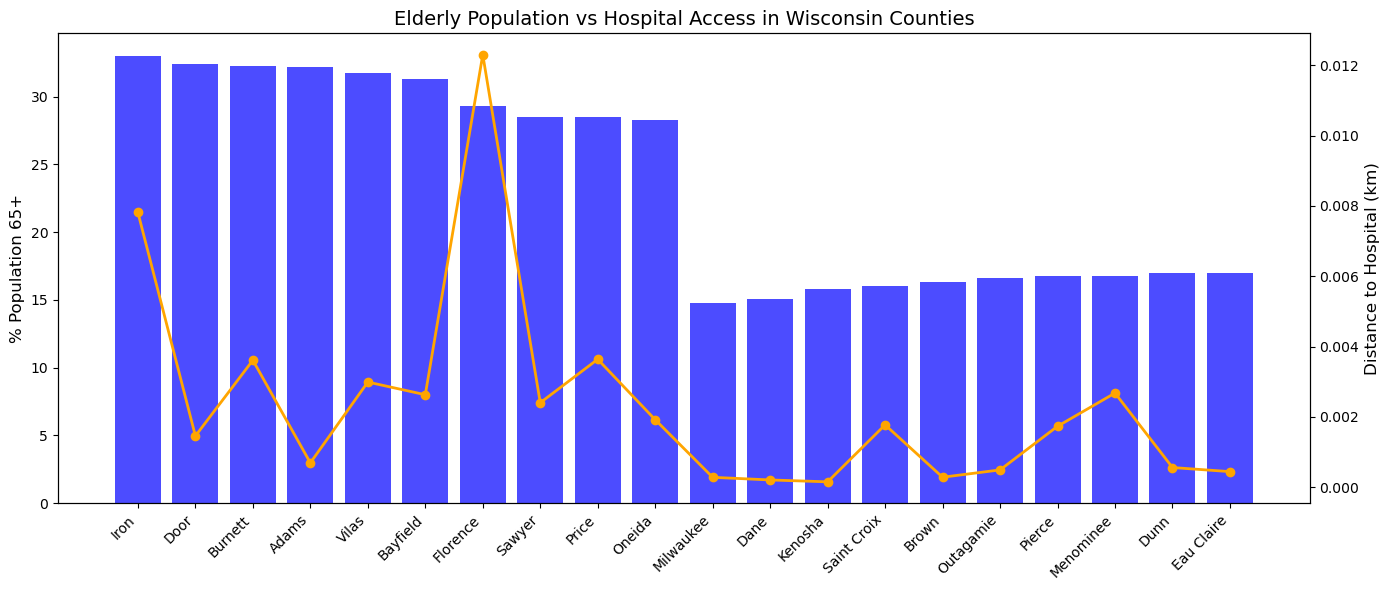

In [89]:
# Setup the data
top10 = county_info.sort_values('pct_65+', ascending=False).head(10)
bottom10 = county_info.sort_values('pct_65+', ascending=True).head(10)
plot_df = pd.concat([top10, bottom10])

# Create plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bars for elderly population
ax1.bar(plot_df['County'], plot_df['pct_65+'] * 100, 
        color='blue', alpha=0.7)
ax1.set_ylabel('% Population 65+', fontsize=12)
ax1.tick_params(axis='y')

# Line for hospital distance
ax2 = ax1.twinx()
ax2.plot(plot_df['County'], plot_df['nearest_hospital_km'], 
         color='orange', marker='o', linewidth=2, markersize=6)
ax2.set_ylabel('Distance to Hospital (km)', fontsize=12)

# Labels and title
ax1.set_xticklabels(plot_df['County'], rotation=45, ha='right')
plt.title('Elderly Population vs Hospital Access in Wisconsin Counties', fontsize=14)
plt.tight_layout()
plt.show()

In the ten oldest counties, such as Florence and Iron, the concentration of residents over 65 exceeds 30%. However, these same counties face significantly higher average distances to the nearest hospital compared to urban centers like Dane and Milwaukee, where the distance to care is negligible. This spatial mismatch suggests that the most clinically vulnerable populations are also the most geographically isolated.

**Poverty vs Mortality**

To evaluate the socioeconomic drivers of health outcomes, this graph examines the relationship between elderly poverty and age-adjusted mortality rates across Wisconsin’s 72 counties. The use of Plotly enables interactivity, allowing users to hover over each point to identify the corresponding county and better explore geographic patterns. Furthermore, the interactive hover data integrates uninsured rates, allowing for a multi-dimensional assessment of how financial barriers and insurance gaps compound to create the state's most severe health disparities

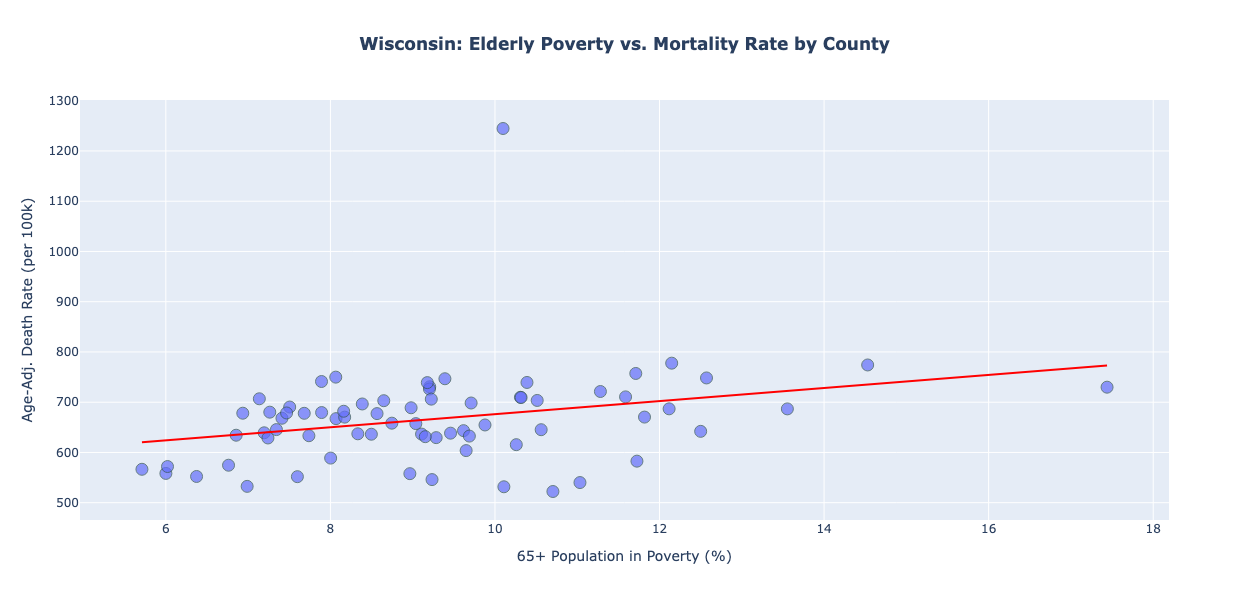

In [90]:
#PLOTTING POVERTY VS MORTALITY
import plotly.express as px

plot_df = county_info.reset_index()

if plot_df['pct_65_poverty'].max() <= 1:
    plot_df['pct_65_poverty'] = plot_df['pct_65_poverty'] * 100

fig = px.scatter(
    plot_df, 
    x='pct_65_poverty', 
    y='death_rate',
    hover_name='County',             
    hover_data={                      
        'pct_65_poverty': ':.1f}%',  
        'death_rate': ':.1f', 
        'pct_uninsured': ':.1f}%', 
        'tot_pop': ':,'               
    },
    trendline='ols',                  
    trendline_color_override='red',
    title='<b>Wisconsin: Elderly Poverty vs. Mortality Rate by County</b>',
    labels={
        'pct_65_poverty': '65+ Population in Poverty (%)',
        'death_rate': 'Age-Adj. Death Rate (per 100k)'
    },
    height=600
)

fig.update_traces(marker=dict(size=12, opacity=0.7, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(title_x=0.5) # Center the title

fig.show()

This graph implements the OLS trendline in addition to the scatter line to reveal a positive correlation suggesting that financial instability among the 65+ cohort is a significant predictor of mortality risk. Since the mortality data is adjusted this trend represents deaths that occur at higher rates than demographically expected. There is one very obvious outlier in this graph, which is Menominee County. Interestingly, the uninsured rate is also fairly low which means the problem isn't necessarily a lack of insurance cards; it’s likely a lack of physical providers or specific systemic barriers. 

**Hospitals and Mortality Rate**

To bridge the gap between demographic vulnerability and physical access, this research utilizes a bivariate geographic approach: a choropleth map of age-adjusted mortality rates overlaid with point-source data for hospital locations. This visualization allows for the immediate identification of 'medical deserts': regions where high mortality rates coincide with a sparse distribution of healthcare facilities.

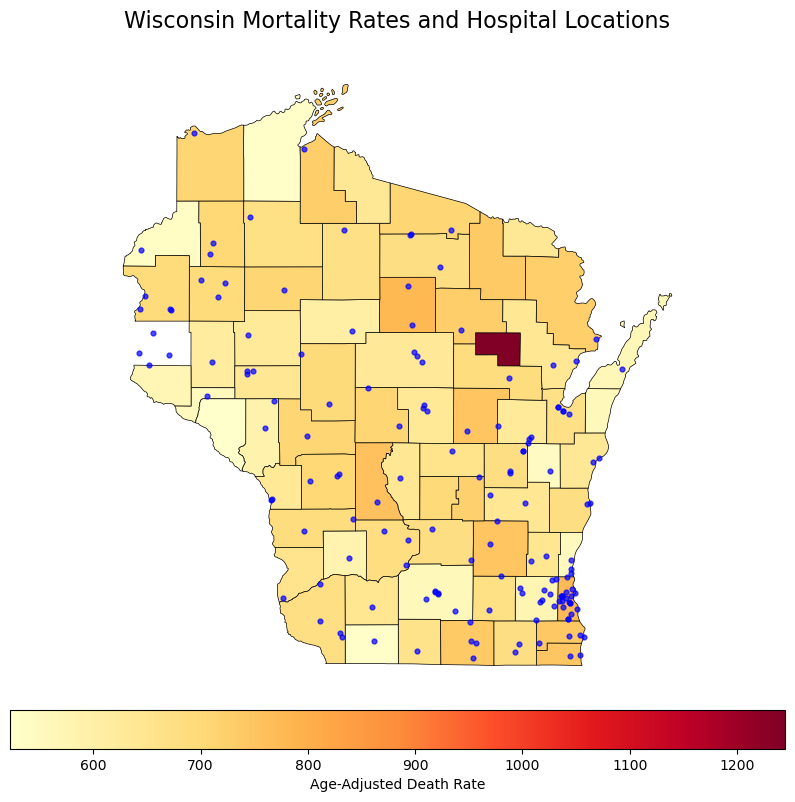

In [25]:
#PLOTTING HOSPTIALS IN WISCONSIN
us = geopandas.read_file('cb_2021_us_county_5m.zip')
wisco = us[us['STATE_NAME'] == 'Wisconsin']
hospitals = geopandas.read_file('Wisconsin_Hospitals.zip')
hospitals = hospitals.to_crs(wisco.crs)

wisco_merged = wisco.merge(county_info, left_on='NAME', right_on='County')

fig, gax = plt.subplots(figsize=(10, 10))

wisco_merged.plot(
    ax=gax, 
    column='death_rate',   
    legend=True, 
    cmap='YlOrRd',  
    edgecolor='black', 
    linewidth=0.5,
    legend_kwds={'label': "Age-Adjusted Death Rate", 'orientation': "horizontal", 'pad': 0.02}
)

hospitals.plot(ax=gax, color='blue', markersize=12, alpha=0.7, label='Hospitals')

gax.axis('off')

plt.title('Wisconsin Mortality Rates and Hospital Locations', fontsize=16, pad=20)
plt.show()

Menominee County stands out as an outlier, with no hospital facility within its borders. This aligns with the earlier visualization, where it appears as a clear deviation from the broader pattern. More broadly, the high concentration of facilities in the urbanized southeast contrasts sharply with the limited access observed in central and northern Wisconsin. Together, these patterns suggest that physical distance may act as a barrier to healthcare access and is associated with higher mortality rates in some of the state’s most underserved regions.

**Hospital Distance vs Mortality Rate**

To examine the relationship between healthcare access and mortality, this figure plots the average distance to the nearest hospital against the age-adjusted mortality rate. While the heat map highlights where hospitals are less accessible, this scatterplot quantifies how distance is associated with variation in mortality across counties.

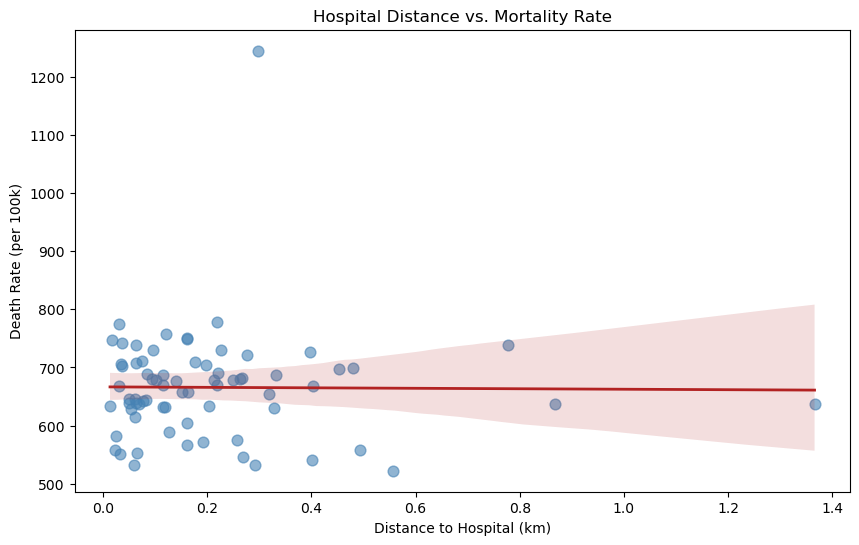

In [91]:
# 1. Setup the data (keep this part)
county_info['dist_km'] = hospital_mort['nearest_hospital_km'] * 111

# 2. Simple Plot
plt.figure(figsize=(10, 6))
sns.regplot(data=county_info, x='dist_km', y='death_rate', scatter_kws={'alpha':0.6, 's':60, 'color':'steelblue'}, line_kws={'color':'firebrick', 'lw':2})

# 3. Basic Labels
plt.title('Hospital Distance vs. Mortality Rate')
plt.xlabel('Distance to Hospital (km)')
plt.ylabel('Death Rate (per 100k)')
plt.show()

This figure examines the relationship between geographic isolation and health outcomes. Although mortality might be expected to rise with distance to care, the OLS trendline is relatively flat with greater variability at higher distances. This suggests that distance alone does not explain mortality differences and is likely mediated by other socioeconomic factors. These patterns motivate the use of a multivariate OLS model that incorporates poverty and insurance status alongside geographic variables.